In [1]:

!pip install pandas numpy scikit-learn matplotlib seaborn scipy prophet --quiet



[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("OMT_MDCD_RY26_P02_V10_YTD24_GEO.csv")

# -------------------------
# Basic cleaning
# -------------------------

# Remove duplicates
df = df.drop_duplicates()

# Convert Year to datetime
df["ds"] = pd.to_datetime(df["Year"].astype(str))

# Target variable
df["y"] = df["LA_Opioid_Prscrbng_Rate"]

# -------------------------
# Missing values
# -------------------------

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# -------------------------
# Encode categorical columns
# -------------------------

df["Geo_Lvl"] = df["Geo_Lvl"].astype("category").cat.codes

df["Plan_Type"] = df["Plan_Type"].astype("category").cat.codes

df["Geo_Cd"] = df["Geo_Cd"].astype("category").cat.codes

# -------------------------
# Feature Engineering
# -------------------------

# Opioid ratio
df["Raw_Opioid_Ratio"] = (
    df["Tot_Opioid_Clms"] /
    df["Tot_Clms"]
)

# Avoid division errors
df["Raw_Opioid_Ratio"] = df["Raw_Opioid_Ratio"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["Raw_Opioid_Ratio"] = (
    df["Raw_Opioid_Ratio"]
    .fillna(df["Raw_Opioid_Ratio"].median())
)

# Sort before lag creation
df = df.sort_values(["Geo_Cd", "Year"])

# -------------------------
# Lag Features
# -------------------------

for lag in [1, 2, 3]:
    df[f"LA_Lag_{lag}"] = (
        df.groupby("Geo_Cd")
        ["LA_Opioid_Prscrbng_Rate"]
        .shift(lag)
    )

# -------------------------
# Rolling Mean
# -------------------------

df["LA_Rolling_Mean_3Y"] = (
    df.groupby("Geo_Cd")
    ["LA_Opioid_Prscrbng_Rate"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

# Fill lag nulls
lag_cols = [
    "LA_Lag_1",
    "LA_Lag_2",
    "LA_Lag_3"
]

for col in lag_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.head())

        Year  Geo_Lvl  Geo_Cd               Geo_Desc  Plan_Type  \
131072  2022        0       0  Alaska:Aleutians West          2   
131073  2022        0       1       Alaska:Anchorage          0   
131074  2022        0       1       Alaska:Anchorage          1   
131075  2022        0       1       Alaska:Anchorage          2   
131076  2022        0       2          Alaska:Bethel          0   

        Tot_Opioid_Clms   Tot_Clms  Opioid_Prscrbng_Rate  \
131072             11.0     6979.0                  0.16   
131073          20545.0  1177506.0                  1.74   
131074          19039.0   682762.0                  2.79   
131075           1506.0   494744.0                  0.30   
131076            985.0   198355.0                  0.50   

        Opioid_Prscrbng_Rate_5Y_Chg  Opioid_Prscrbng_Rate_1Y_Chg  ...  \
131072                        -2.89                        -0.38  ...   
131073                        -2.89                        -1.83  ...   
131074           

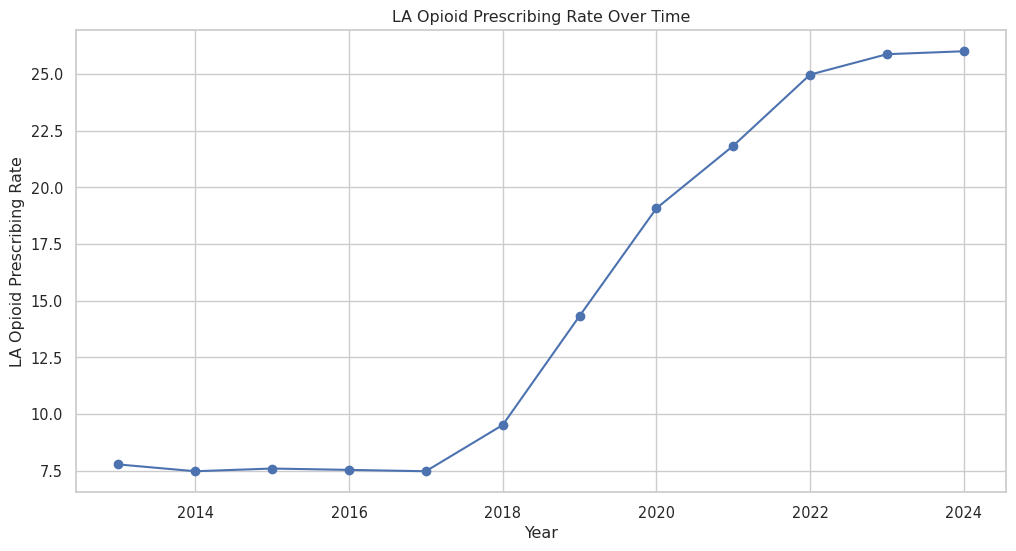

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("OMT_MDCD_RY26_P02_V10_YTD24_GEO.csv")

# Example: National + All plans
temp = df[
    (df["Geo_Lvl"] == "National") &
    (df["Plan_Type"] == "All")
].copy()

temp = temp.sort_values("Year")

plt.figure(figsize=(12,6))
plt.plot(
    temp["Year"],
    temp["LA_Opioid_Prscrbng_Rate"],
    marker="o"
)

plt.title("LA Opioid Prescribing Rate Over Time")
plt.xlabel("Year")
plt.ylabel("LA Opioid Prescribing Rate")
plt.grid(True)

plt.show()

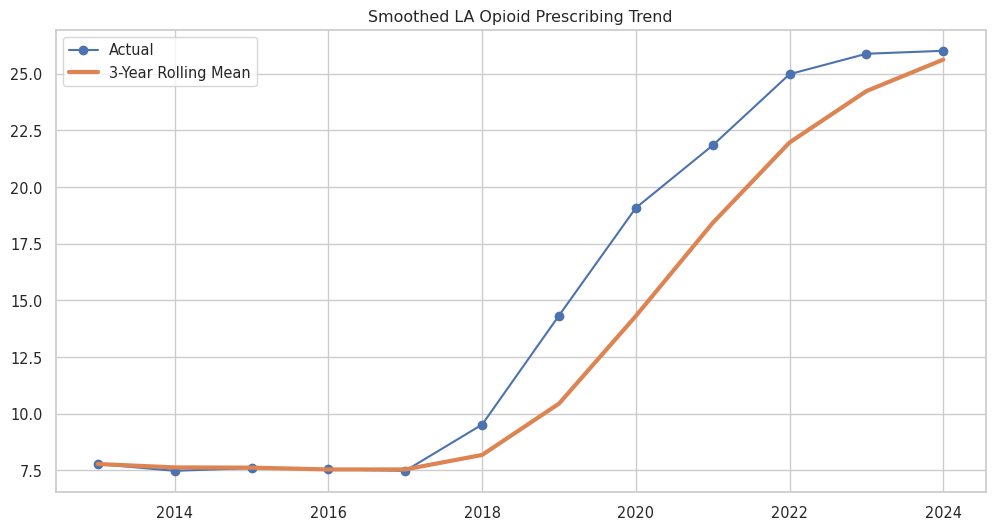

In [ ]:
temp["Rolling_3Y"] = (
    temp["LA_Opioid_Prscrbng_Rate"]
    .rolling(window=3, min_periods=1)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    temp["Year"],
    temp["LA_Opioid_Prscrbng_Rate"],
    marker="o",
    label="Actual"
)

plt.plot(
    temp["Year"],
    temp["Rolling_3Y"],
    linewidth=3,
    label="3-Year Rolling Mean"
)

plt.legend()
plt.grid(True)

plt.title("Smoothed LA Opioid Prescribing Trend")
plt.show()

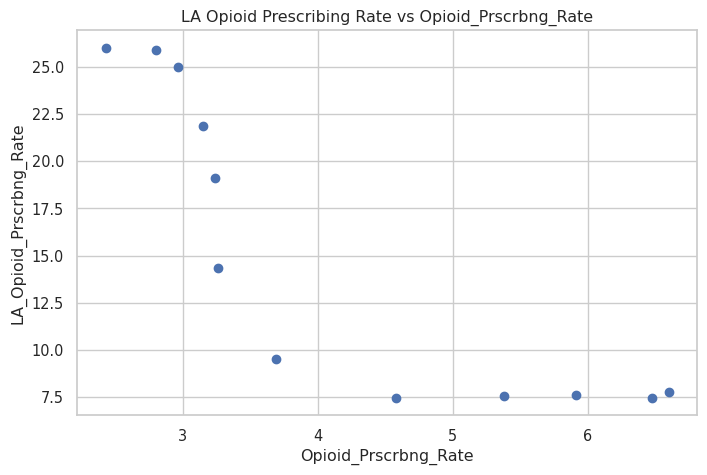

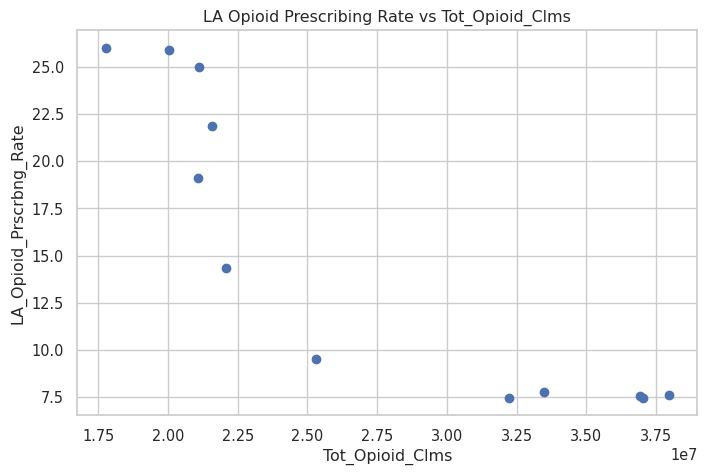

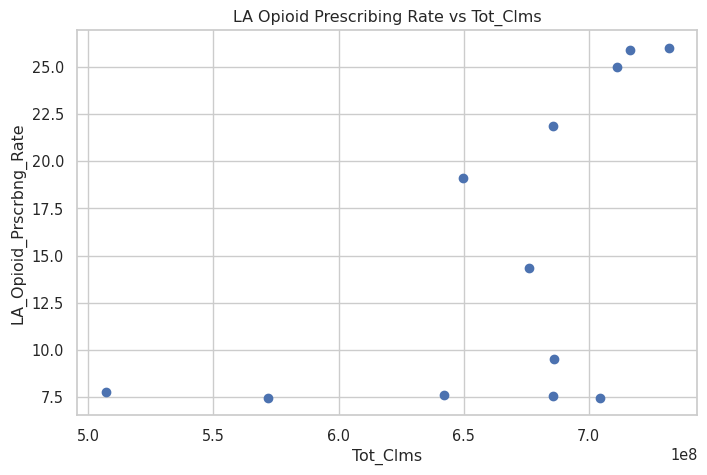

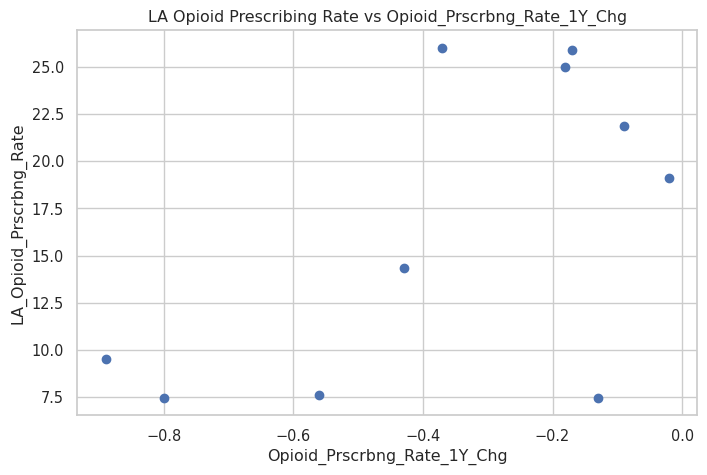

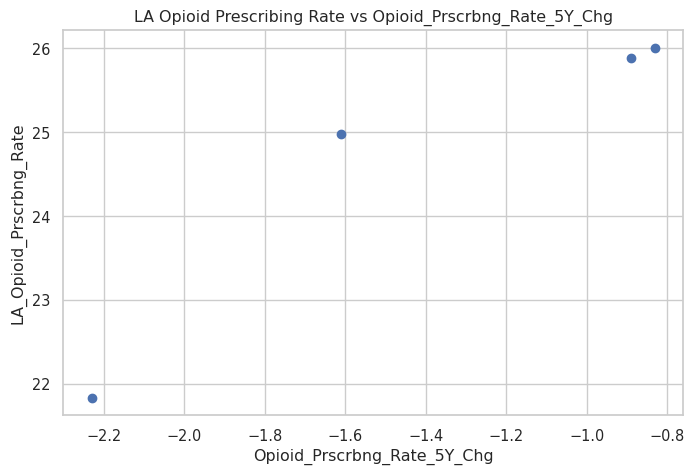

In [ ]:
features = [
    "Opioid_Prscrbng_Rate",
    "Tot_Opioid_Clms",
    "Tot_Clms",
    "Opioid_Prscrbng_Rate_1Y_Chg",
    "Opioid_Prscrbng_Rate_5Y_Chg"
]

for col in features:

    plt.figure(figsize=(8,5))

    plt.scatter(
        temp[col],
        temp["LA_Opioid_Prscrbng_Rate"]
    )

    plt.xlabel(col)
    plt.ylabel("LA_Opioid_Prscrbng_Rate")

    plt.title(
        f"LA Opioid Prescribing Rate vs {col}"
    )

    plt.grid(True)

    plt.show()

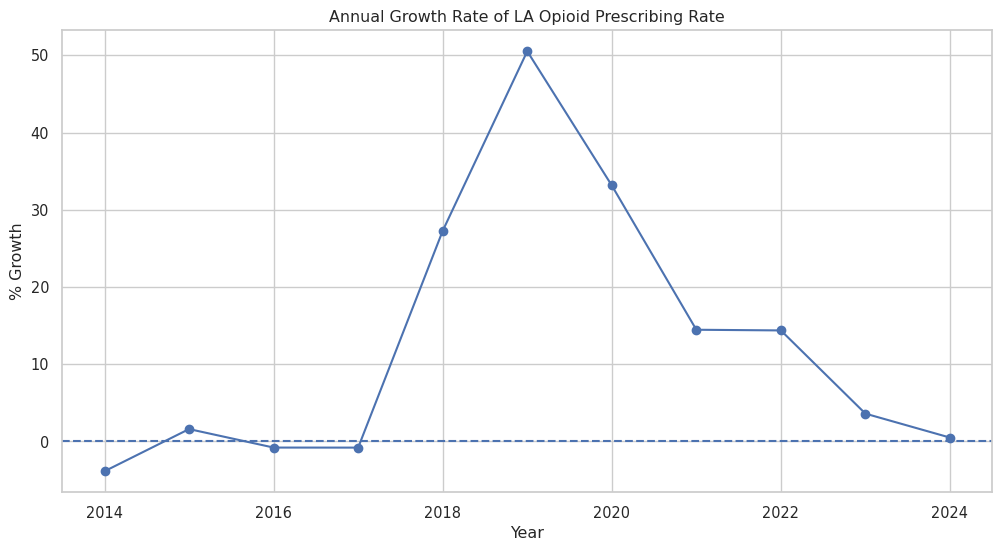

In [ ]:
temp["Growth"] = (
    temp["LA_Opioid_Prscrbng_Rate"]
    .pct_change()
    * 100
)

plt.figure(figsize=(12,6))

plt.plot(
    temp["Year"],
    temp["Growth"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Annual Growth Rate of LA Opioid Prescribing Rate"
)

plt.xlabel("Year")
plt.ylabel("% Growth")

plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import pickle

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("OMT_MDCD_RY26_P02_V10_YTD24_GEO.csv")

# National + All Plans
df = df[
    (df["Geo_Lvl"] == "National") &
    (df["Plan_Type"] == "All")
].copy()

# =====================================================
# PREPARE PROPHET FORMAT
# =====================================================

df["ds"] = pd.to_datetime(df["Year"].astype(str))

df["y"] = df["LA_Opioid_Prscrbng_Rate"]

# =====================================================
# FEATURE ENGINEERING
# =====================================================

df["Raw_Opioid_Ratio"] = (
    df["Tot_Opioid_Clms"] /
    df["Tot_Clms"]
)

df["Raw_Opioid_Ratio"] = (
    df["Raw_Opioid_Ratio"]
    .replace([np.inf, -np.inf], np.nan)
)

# Fill missing values
df["Raw_Opioid_Ratio"] = (
    df["Raw_Opioid_Ratio"]
    .fillna(df["Raw_Opioid_Ratio"].median())
)

# =====================================================
# USE ONLY STRONG REGRESSORS
# =====================================================

features = [
    "Opioid_Prscrbng_Rate",
    "Raw_Opioid_Ratio"
]

# Fill NaN
for col in features:
    df[col] = df[col].fillna(df[col].median())

# =====================================================
# FINAL DATAFRAME
# =====================================================

prophet_df = df[
    ["ds", "y"] + features
].copy()

prophet_df = prophet_df.sort_values("ds")

print("Total observations:", len(prophet_df))

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

train = prophet_df[
    prophet_df["ds"] < "2023-01-01"
]

test = prophet_df[
    prophet_df["ds"] >= "2023-01-01"
]

print("Train size:", len(train))
print("Test size :", len(test))

# =====================================================
# MODEL
# =====================================================

model = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

for col in features:
    model.add_regressor(col)

# =====================================================
# TRAIN
# =====================================================

print("\nTraining Prophet...")

model.fit(train)

print("Training complete.")

# =====================================================
# PREDICT
# =====================================================

forecast = model.predict(test)

# =====================================================
# EVALUATION
# =====================================================

y_true = test["y"]
y_pred = forecast["yhat"]

mae = mean_absolute_error(
    y_true,
    y_pred
)

mse = mean_squared_error(
    y_true,
    y_pred
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    y_true,
    y_pred
) * 100

r2 = r2_score(
    y_true,
    y_pred
)
accuracy = 100 - mape

print("\n========== METRICS ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")
print(f"Accuracy : {accuracy:.2f}%") 
# =====================================================
# ACTUAL VS PREDICTED
# =====================================================

results = pd.DataFrame({
    "Year": test["ds"].dt.year,
    "Actual": y_true.values,
    "Predicted": y_pred.values
})

results["Error"] = (
    results["Actual"]
    - results["Predicted"]
)

print("\n========== ACTUAL VS PREDICTED ==========")
print(results)

# =====================================================
# SAVE MODEL
# =====================================================

with open(
    "opioidoracle_prophet.pkl",
    "wb"
) as f:
    pickle.dump(model, f)

print("\nModel saved.")

# =====================================================
# SAVE FORECASTS
# =====================================================

forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].to_csv(
    "opioidoracle_forecasts.csv",
    index=False
)

print("Forecasts saved.")

C:\Users\vukri\AppData\Local\Temp\ipykernel_29000\278248586.py:18: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("OMT_MDCD_RY26_P02_V10_YTD24_GEO.csv")


Total observations: 12
Train size: 10
Test size : 2


22:00:40 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet...


22:00:41 - cmdstanpy - INFO - Chain [1] done processing


Training complete.

========== METRICS ==========
MAE  : 3.3619
MSE  : 12.5385
RMSE : 3.5410
MAPE : 12.95%
R²   : -2966.6932

========== ACTUAL VS PREDICTED ==========
       Year  Actual  Predicted     Error
58560  2023   25.88  28.130020 -2.250020
0      2024   26.01  30.483748 -4.473748

Model saved.
Forecasts saved.
